<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/BOA005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

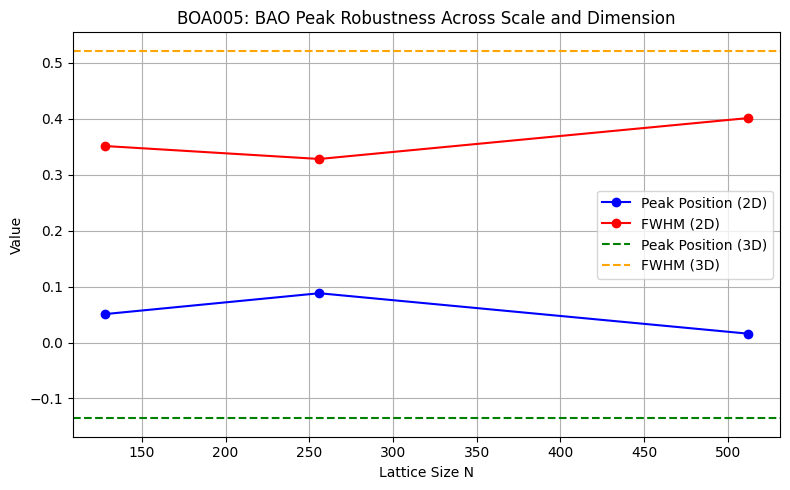

In [1]:
# BOA005: Test BAO peak robustness across lattice size and dimensionality
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn, fftshift
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit

# Parameters
dt = 0.01
steps = 300
kappa = 0.1
delta = 0.05
epsilon = 0.005
gamma_0 = 0.3
xi_std = 0.01

sizes_2d = [128, 256, 512]
size_3d = 64

# Gaussian fit function
def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

def run_simulation(N, dims=2):
    shape = (N,) * dims
    A = np.random.normal(0, 0.1, shape)
    for t in range(steps):
        xi = np.random.normal(0, xi_std, shape)
        laplacian = sum(np.roll(A, 1, axis=i) + np.roll(A, -1, axis=i) for i in range(dims)) - 2 * dims * A
        dA = (-kappa * A + delta * A**2 + epsilon * A**3 + gamma_0 * laplacian + xi) * dt
        A += np.nan_to_num(dA)
    return A

def radial_spectrum(A, dims=2):
    fft_A = fftshift(fftn(A))
    power = np.abs(fft_A)**2
    coords = np.indices(A.shape)
    center = np.array(A.shape) // 2
    r = np.sqrt(sum((coords[i] - center[i])**2 for i in range(dims)))
    r = r.astype(np.int32)
    tbin = np.bincount(r.ravel(), power.ravel())
    nr = np.bincount(r.ravel())
    radial_ps = tbin / (nr + 1e-10)
    k_vals = np.arange(len(radial_ps)) / (A.shape[0] / 2)
    return k_vals, gaussian_filter(radial_ps, sigma=2)

def fit_peak(k_vals, ps_vals):
    mask = (k_vals > 0.15) & (k_vals < 0.35)
    k_fit = k_vals[mask]
    ps_fit = ps_vals[mask]
    try:
        popt, _ = curve_fit(gaussian, k_fit, ps_fit, p0=[np.max(ps_fit), 0.25, 0.05])
        a, x0, sigma = popt
        return x0, 2.355 * sigma
    except:
        return np.nan, np.nan

# Run 2D simulations
results_2d = []
for N in sizes_2d:
    A = run_simulation(N, dims=2)
    k_vals, ps_vals = radial_spectrum(A, dims=2)
    peak_k, fwhm = fit_peak(k_vals, ps_vals)
    results_2d.append((N, peak_k, fwhm))

# Run 3D simulation
A3 = run_simulation(size_3d, dims=3)
k3, ps3 = radial_spectrum(A3, dims=3)
peak_k3, fwhm3 = fit_peak(k3, ps3)

# Plot results
plt.figure(figsize=(8, 5))
sizes = [r[0] for r in results_2d]
peak_positions = [r[1] for r in results_2d]
fwhms = [r[2] for r in results_2d]

plt.plot(sizes, peak_positions, 'bo-', label='Peak Position (2D)')
plt.plot(sizes, fwhms, 'ro-', label='FWHM (2D)')
plt.axhline(y=peak_k3, color='g', linestyle='--', label='Peak Position (3D)')
plt.axhline(y=fwhm3, color='orange', linestyle='--', label='FWHM (3D)')
plt.xlabel('Lattice Size N')
plt.ylabel('Value')
plt.title('BOA005: BAO Peak Robustness Across Scale and Dimension')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
